# 🤖 AutoGluon — AutoML for Tabular Data *(optional)*

> **What you'll learn:** what AutoML really automates (a model zoo, hyperparameters, k-fold bagging, multi-layer stacking, weighted ensembles) and what it can't (framing, leakage, features, business metrics); how to drive AutoGluon's `TabularPredictor` end to end; how to read a leaderboard honestly; why bagging keeps stacking leakage-free (you'll prove it and build stacking yourself); feature importance and decision thresholds; and the deployment price of a big ensemble — measured in milliseconds and megabytes.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate |
| **Time** | ~3 hours to read and run, +1.5 hours for exercises and the project |
| **Prerequisites** | [Optuna](01_Optuna.ipynb) (tuning, validation discipline) · [Gradient Boosting](../03_Classical_Machine_Learning/10_Gradient_Boosting.ipynb) (LightGBM/XGBoost/CatBoost) |
| **Tested with** | Python 3.12 · autogluon.tabular 1.6.1 (in its own environment) · scikit-learn 1.9 · pandas 2.3 · lightgbm 4.7 · matplotlib |
| **Interview relevance** | ⭐⭐ Medium — "how does stacking avoid leakage?", "would you ship an AutoML ensemble?", "AutoML beat your model — now what?", "what can't AutoML do for you?" |

## 🤔 What Is AutoGluon?

**AutoML** (automated machine learning) tools take a table and a target column and do the repetitive part of modelling for you: try many model types, pick hyperparameters, and combine the best models.

**AutoGluon** (open source, from AWS) is one of the strongest AutoML systems for tabular data. Its core trick is not clever hyperparameter search but **ensembling**: train a varied "zoo" of solid models (LightGBM, CatBoost, XGBoost, random forests, extra trees, k-NN, neural networks), then **stack** them — a second layer of models learns from the first layer's predictions — using **k-fold bagging** so no model ever grades itself on data it trained on.

**Analogy — a panel of doctors.** One specialist can miss things. A hospital asks several specialists (base models), and a senior doctor (the stacker) learns *whose opinion to trust for which kind of patient*. The senior doctor must learn this from cases the specialists had **not** already seen — otherwise every specialist looks perfect. That rule is the whole point of out-of-fold predictions.

```
 train data ─► Layer 1: LightGBM  CatBoost  XGBoost  RF  ExtraTrees   (each bagged: 5 folds → out-of-fold predictions)
                   │         │        │       │      │
                   └─────────┴── OOF predictions + original features ──┐
                                                                        ▼
               Layer 2: LightGBM_L2  RF_L2 …   (again bagged)  ──►  WeightedEnsemble (greedy weights) ──► prediction
```

## 🎯 Why It Matters

- **Strong baselines in minutes.** On tabular benchmarks, AutoGluon with a time budget is hard to beat by hand. Knowing *how good* a problem can get quickly tells you whether more modelling is worth it.
- **The techniques are general.** k-fold bagging, out-of-fold stacking, greedy ensemble selection, and permutation importance are Kaggle-winning tools you can use without AutoML.
- **Deployment trade-offs are real.** A 20-model stack can be 100× slower and larger than one LightGBM. MLEs are expected to measure that and decide.
- **In interviews** AutoML comes up as: *"how does stacking avoid leakage?"*, *"AutoML or a hand-built model for production?"*, *"what does AutoML not do?"*, *"your AutoML validation score is 0.95 but production is 0.80 — why?"*.

## ✅ By the End You Can

- [ ] Train, evaluate, save, and reload a `TabularPredictor` under a time budget and CPU cap
- [ ] Read a leaderboard — validation vs held-out scores, fit and inference time — without fooling yourself
- [ ] Explain k-fold bagging and multi-layer stacking, and verify out-of-fold predictions are leakage-free
- [ ] Build a 2-level stacking ensemble from scratch and check it against scikit-learn
- [ ] Use feature importance and decision thresholds, and measure latency/disk trade-offs with `refit_full` and deployment clones
- [ ] Decide when AutoML is a baseline and when it is the final model

## 📋 Table of Contents

1. [What AutoML Automates — and What It Doesn't](#1.-What-AutoML-Automates-—-and-What-It-Doesn't-🟢)
2. [TabularPredictor End to End](#2.-TabularPredictor-End-to-End-🟢)
3. [Presets and Time Budgets](#3.-Presets-and-Time-Budgets-🟡)
4. [Reading the Leaderboard](#4.-Reading-the-Leaderboard-🟡)
5. [k-Fold Bagging and Multi-Layer Stacking](#5.-k-Fold-Bagging-and-Multi-Layer-Stacking-🔴)
6. [Feature Importance](#6.-Feature-Importance-🟢)
7. [Probabilities and Decision Thresholds](#7.-Probabilities-and-Decision-Thresholds-🟡)
8. [Deployment Trade-offs: refit_full, Clones, Latency, Disk](#8.-Deployment-Trade-offs:-refit_full,-Clones,-Latency,-Disk-🔴)
9. [AutoML as a Baseline vs a Final Model](#9.-AutoML-as-a-Baseline-vs-a-Final-Model-🟢)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-AutoGluon-vs-a-Hand-Tuned-LightGBM-on-Adult-Income) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

**Install AutoGluon in its own virtual environment.** AutoGluon pins its own versions of pandas, scikit-learn and the boosting libraries (this notebook was run with pandas 2.3, while the rest of the course uses pandas 3), so installing it into the main course environment can break other notebooks. From the repository root:

```bash
python3.12 -m venv .venvs/autogluon
.venvs/autogluon/bin/pip install "autogluon.tabular[lightgbm,catboost,xgboost]==1.6.*" matplotlib ipykernel
.venvs/autogluon/bin/python -m ipykernel install --user --name autogluon --display-name "Python (autogluon)"
```

Then pick the **Python (autogluon)** kernel for this notebook.

- This environment has **no PyTorch/fastai**, so AutoGluon's two neural-network model types are excluded (`NN_TORCH`, `FASTAI`). On small tabular data they rarely change the result under short time budgets. AutoGluon also probes for a GPU through PyTorch and logs *"Failed to import torch"* when it isn't installed — we silence that one logger because it only means "0 GPUs".
- Every `fit` is capped at **4 CPUs** and a short `time_limit`, so the notebook runs in roughly 8–10 minutes. Predictors are saved under `_outputs/autogluon/` (ignored by git).
- `check()` gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "autogluon.tabular[lightgbm,catboost,xgboost]>=1.4" matplotlib   # run inside a SEPARATE environment (see above)

import logging
import os
import shutil
import sys
import time
from pathlib import Path

import autogluon.tabular
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from autogluon.tabular import TabularPredictor
from sklearn.datasets import fetch_openml
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

print(f"Python {sys.version.split()[0]} | AutoGluon {autogluon.tabular.__version__} | scikit-learn {sklearn.__version__} | "
      f"pandas {pd.__version__} | LightGBM {lgb.__version__}")

logging.getLogger("autogluon.common.utils.resource_utils").setLevel(logging.CRITICAL)   # "no torch → 0 GPUs" message
SEED = 0
NUM_CPUS = 4
EXCLUDED_MODELS = ["NN_TORCH", "FASTAI"]                                  # need torch/fastai, not installed here
OUTPUT_DIR = Path("_outputs") / "autogluon"
shutil.rmtree(OUTPUT_DIR, ignore_errors=True)
OUTPUT_DIR.mkdir(parents=True)
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.width", 160)


def dir_size_mb(path):
    return sum(f.stat().st_size for f in Path(path).rglob("*") if f.is_file()) / 1e6


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (str, bool)):
        ok = got == expected
    else:
        got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if got_arr.shape != exp_arr.shape:
            raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
        ok = np.allclose(got_arr, exp_arr, atol=1e-6)
    assert ok, f"❌ {name}: not quite (got {got!r}). {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | AutoGluon 1.6.1 | scikit-learn 1.9.1 | pandas 2.3.3 | LightGBM 4.7.0


## 1. What AutoML Automates — and What It Doesn't 🟢

| AutoML **does** (AutoGluon) | AutoML does **not** — that's still your job |
|---|---|
| Detect problem type (binary / multiclass / regression) and column types | **Frame the problem**: what is the label, who uses the prediction, what decision does it drive? |
| Clean basics: missing values, categorical encoding, dates, text n-grams | Spot **leakage**: IDs, post-outcome columns, time travel across train/test |
| Train a zoo of models with good default hyperparameters | Build **domain features** (ratios, aggregates, history windows) |
| k-fold **bagging**, multi-layer **stacking**, **weighted ensembles** | Choose the **business metric** and the decision **threshold** (cost of FP vs FN) |
| Respect a time budget; rank models on a validation set | Design a **trustworthy split** (by time, by customer) and keep the test set untouched |
| Save/load, refit on all data, report feature importance | Monitoring, fairness review, latency/cost limits in production |

**Dataset — Adult income (OpenML 1590).** 48,842 people from the 1994 US census, 14 features (age, education, occupation, hours per week, …), label: income `>50K` or not. It has real missing values and categorical columns. We split it once:

- **train (60%)** — everything models learn from
- **dev (20%)** — our held-out set for comparing approaches while learning (AutoGluon never sees it)
- **test (20%)** — touched **once**, in the mini project

In [2]:
adult = fetch_openml(data_id=1590, as_frame=True)                        # ~2 MB download on first run, then cached
data = adult.frame.rename(columns={"class": "income"})
data["income"] = data["income"].astype(str)                               # '>50K' / '<=50K' as plain strings
print(data.shape)
print(data.head(3).to_string())
print("\nmissing values:", data.isna().sum()[lambda s: s > 0].to_dict())
print("label balance:", data["income"].value_counts(normalize=True).round(3).to_dict())

LABEL = "income"
train_df, rest_df = train_test_split(data, test_size=0.4, stratify=data[LABEL], random_state=SEED)
dev_df, test_df = train_test_split(rest_df, test_size=0.5, stratify=rest_df[LABEL], random_state=SEED)
train_small = train_df.sample(10_000, random_state=SEED)                  # smaller copy keeps the concept sections fast
print(f"\ntrain {len(train_df):,} | dev {len(dev_df):,} | test {len(test_df):,} | train_small {len(train_small):,}")

(48842, 15)
   age  workclass  fnlwgt   education  education-num      marital-status         occupation relationship   race   sex  capital-gain  capital-loss  hours-per-week native-country income
0   25    Private  226802        11th              7       Never-married  Machine-op-inspct    Own-child  Black  Male             0             0              40  United-States  <=50K
1   38    Private   89814     HS-grad              9  Married-civ-spouse    Farming-fishing      Husband  White  Male             0             0              50  United-States  <=50K
2   28  Local-gov  336951  Assoc-acdm             12  Married-civ-spouse    Protective-serv      Husband  White  Male             0             0              40  United-States   >50K

missing values: {'workclass': 2799, 'occupation': 2809, 'native-country': 857}
label balance: {'<=50K': 0.761, '>50K': 0.239}

train 29,305 | dev 9,768 | test 9,769 | train_small 10,000


### ✍️ Your Turn

What fraction of `train_df` earns `>50K`? Store it in `positive_rate`. (Any metric you report later should be compared with what this "base rate" gives for free.)

In [3]:
positive_rate = None  # TODO: your code here
check("positive_rate", positive_rate, (train_df[LABEL] == ">50K").sum() / len(train_df), hint="(train_df[LABEL] == '>50K').mean()")

⏳ positive_rate: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
positive_rate = (train_df[LABEL] == ">50K").mean()
check("positive_rate", positive_rate, (train_df[LABEL] == ">50K").sum() / len(train_df))
```

About 24%: a model that always says `<=50K` is ~76% accurate, which is why we'll use ROC AUC rather than accuracy.
</details>

> 💡 **Interview angle:** "What can't AutoML do for you?" — framing, leakage detection, domain features, the right split and business metric, thresholds, and production concerns. AutoML optimises a metric on the data you give it; garbage (or leaky) in, confident garbage out.

## 2. TabularPredictor End to End 🟢

Three calls: **create** (`label`, `eval_metric`, `path`), **fit** (data, `time_limit`, `presets`, `num_cpus`), **use** (`predict`, `predict_proba`, `evaluate`). No encoding or imputation needed — AutoGluon infers column types itself.

In [4]:
start = time.perf_counter()
predictor = TabularPredictor(label=LABEL, eval_metric="roc_auc", path=str(OUTPUT_DIR / "quickstart"), verbosity=0).fit(
    train_small,
    presets="medium_quality",                 # fast preset: no bagging/stacking
    time_limit=60,                            # seconds for the WHOLE fit
    num_cpus=NUM_CPUS,
    excluded_model_types=EXCLUDED_MODELS,
)
quick_fit_seconds = time.perf_counter() - start

print(f"fit took {quick_fit_seconds:.0f} s (limit 60 s) | problem type: {predictor.problem_type} | positive class: {predictor.positive_class}")
print("models trained:", predictor.model_names())
print("best model    :", predictor.model_best)
print("saved to      :", os.path.relpath(predictor.path))

X_dev = dev_df.drop(columns=LABEL)
print("\npredictions   :", predictor.predict(X_dev.head(5)).tolist())
print("probabilities :\n", predictor.predict_proba(X_dev.head(5)).round(3).to_string())
quick_scores = predictor.evaluate(dev_df)                                  # dev = data the predictor never saw
print("\ndev metrics:", {k: round(float(v), 4) for k, v in quick_scores.items()})

fit took 18 s (limit 60 s) | problem type: binary | positive class: >50K
models trained: ['LightGBMXT', 'LightGBM', 'RandomForestGini', 'RandomForestEntr', 'CatBoost', 'ExtraTreesGini', 'ExtraTreesEntr', 'XGBoost', 'LightGBMLarge', 'WeightedEnsemble_L2']
best model    : WeightedEnsemble_L2
saved to      : _outputs/autogluon/quickstart

predictions   : ['>50K', '<=50K', '<=50K', '<=50K', '>50K']
probabilities :
        <=50K   >50K
541    0.254  0.746
41843  0.935  0.065
17833  0.988  0.012
42206  0.833  0.167
44254  0.262  0.738

dev metrics: {'roc_auc': 0.9208, 'accuracy': 0.866, 'balanced_accuracy': 0.7839, 'mcc': 0.612, 'f1': 0.6911, 'precision': 0.7705, 'recall': 0.6264}


In [5]:
features = predictor.feature_metadata                                       # what AutoGluon inferred about each column
print("column types it detected:", {k: v for k, v in features.get_type_group_map_raw().items() if v})
reloaded = TabularPredictor.load(predictor.path, verbosity=0)
same = np.allclose(reloaded.predict_proba(X_dev).to_numpy(), predictor.predict_proba(X_dev).to_numpy())
print("reloaded predictor gives identical probabilities:", same)

column types it detected: {'int': ['age', 'fnlwgt', 'education-num', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week'], 'category': ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'native-country']}


reloaded predictor gives identical probabilities: True


`predict_proba` returns one column per class; for binary problems the **positive class** (here `>50K`, the second label alphabetically) is the one `roc_auc` scores. Always check `predictor.positive_class` before using a column.

> 💡 **Interview angle:** "How would you get a strong baseline on a new tabular problem in an hour?" — clean split first, then AutoGluon (or a default LightGBM) with a time limit and a held-out set; read the leaderboard and feature importance to learn where the signal is before hand-engineering anything.

## 3. Presets and Time Budgets 🟡

**Presets** bundle many settings. The real definitions from the installed version:

In [6]:
from autogluon.tabular.configs.presets_configs import tabular_presets_dict

for name in ["medium_quality", "good_quality", "high_quality", "best_quality", "optimize_for_deployment"]:
    print(f"{name:25s} {tabular_presets_dict[name]}")

medium_quality            {'auto_stack': False}
good_quality              {'auto_stack': True, 'dynamic_stacking': 'auto', 'hyperparameters': 'light', 'time_limit': 3600, 'refit_full': True, 'set_best_to_refit_full': True, 'save_bag_folds': False}
high_quality              {'auto_stack': True, 'dynamic_stacking': 'auto', 'hyperparameters': 'zeroshot', 'time_limit': 3600, 'refit_full': True, 'set_best_to_refit_full': True, 'save_bag_folds': False}
best_quality              {'auto_stack': True, 'dynamic_stacking': 'auto', 'hyperparameters': 'zeroshot', 'time_limit': 3600}
optimize_for_deployment   {'keep_only_best': True, 'save_space': True}


How to read them:
- `medium_quality` — no bagging or stacking (`auto_stack=False`): one holdout split, fastest.
- `good` / `high` / `best_quality` — `auto_stack=True` turns on **k-fold bagging and stacking**; `dynamic_stacking` first checks on a sub-split whether stacking overfits; `hyperparameters` picks a larger model portfolio (`zeroshot` = configurations pre-selected on hundreds of benchmark datasets). `high`/`good` also `refit_full` for faster inference. Their default `time_limit` is an hour.
- `optimize_for_deployment` — keep only the best model and delete training artefacts.

**The time budget matters as much as the preset.** Same preset, a much shorter limit:

In [7]:
start = time.perf_counter()
rushed = TabularPredictor(label=LABEL, eval_metric="roc_auc", path=str(OUTPUT_DIR / "rushed"), verbosity=0).fit(
    train_small, presets="medium_quality", time_limit=4, num_cpus=NUM_CPUS, excluded_model_types=EXCLUDED_MODELS)
rushed_seconds = time.perf_counter() - start
budget_table = pd.DataFrame([
    {"time_limit": 60, "seconds used": round(quick_fit_seconds, 1), "models": len(predictor.model_names()), "best": predictor.model_best,
     "dev AUC": round(predictor.evaluate(dev_df)["roc_auc"], 4)},
    {"time_limit": 4, "seconds used": round(rushed_seconds, 1), "models": len(rushed.model_names()), "best": rushed.model_best,
     "dev AUC": round(rushed.evaluate(dev_df)["roc_auc"], 4)},
])
print(budget_table.to_string(index=False))
skipped = sorted(set(predictor.model_names()) - set(rushed.model_names()))
print("models skipped with the 4 s budget:", skipped if skipped else "none — every model still fit in time on this machine")
shutil.rmtree(rushed.path)                                                  # not needed again

 time_limit  seconds used  models                best  dev AUC
         60          18.3      10 WeightedEnsemble_L2   0.9208
          4           4.1       6 WeightedEnsemble_L2   0.9202
models skipped with the 4 s budget: ['ExtraTreesEntr', 'ExtraTreesGini', 'LightGBMLarge', 'XGBoost']


With `medium_quality` AutoGluon stops as soon as its model list is done, so a generous limit isn't always used. With a tight limit it trains models in its priority order and skips the rest — the leaderboard only contains what fit in time.

> 💡 **Interview angle:** "Which preset would you use?" — `medium_quality` for quick iteration and debugging the data pipeline; `best_quality` with a long budget for maximum accuracy (competitions, offline scoring); `high_quality` or `refit_full`/deployment options when inference latency matters. Always set `time_limit` and CPU caps on shared machines.

## 4. Reading the Leaderboard 🟡

`leaderboard(data)` lists every model. The columns that matter:

| Column | Meaning |
|---|---|
| `score_val` | score on AutoGluon's **internal validation** data (holdout split, or out-of-fold when bagging) — what it used to rank and ensemble models |
| `score_test` | score on the `data` you pass in — here our **dev** set, never seen during fit |
| `fit_time`, `pred_time_val`, `pred_time_test` | cost of training and of predicting (including models this one depends on) |
| `*_marginal` | the cost of this model alone, excluding its inputs |
| `stack_level`, `can_infer` | layer in the stack; whether it can predict on its own |

In [8]:
board = predictor.leaderboard(dev_df)
print(board[["model", "score_test", "score_val", "pred_time_test", "fit_time", "stack_level"]].round(4).to_string(index=False))

info = predictor.info()
print(f"\ninternal validation rows: {info['num_rows_val']} (holdout carved from the {info['num_rows_train'] + info['num_rows_val']:,} rows we passed)")
rank_corr = board[["score_val", "score_test"]].corr(method="spearman").iloc[0, 1]
top_val, top_dev = board.loc[board["score_val"].idxmax(), "model"], board.loc[board["score_test"].idxmax(), "model"]
print(f"Spearman rank correlation between validation and dev scores: {rank_corr:.2f}")
print(f"best by validation: {top_val} | best on dev: {top_dev}")
ens = board.set_index("model").loc[predictor.model_best]
print(f"{predictor.model_best}: validation {ens['score_val']:.4f} vs dev {ens['score_test']:.4f} (gap {ens['score_val'] - ens['score_test']:+.4f})")

              model  score_test  score_val  pred_time_test  fit_time  stack_level
WeightedEnsemble_L2      0.9208     0.9266          0.0383   11.3990            2
            XGBoost      0.9203     0.9231          0.0106    0.6500            1
           CatBoost      0.9201     0.9247          0.0060    4.0976            1
           LightGBM      0.9182     0.9250          0.0055    2.5368            1
         LightGBMXT      0.9144     0.9209          0.0087    2.7612            1
      LightGBMLarge      0.9143     0.9214          0.0152    4.0821            1
   RandomForestEntr      0.9028     0.9039          0.0487    0.3818            1
   RandomForestGini      0.9017     0.9013          0.0533    1.8387            1
     ExtraTreesGini      0.8960     0.8942          0.0610    0.2857            1
     ExtraTreesEntr      0.8958     0.8962          0.0619    0.2834            1



internal validation rows: 1000 (holdout carved from the 10,000 rows we passed)
Spearman rank correlation between validation and dev scores: 0.93
best by validation: WeightedEnsemble_L2 | best on dev: WeightedEnsemble_L2
WeightedEnsemble_L2: validation 0.9266 vs dev 0.9208 (gap +0.0058)


Two habits: compare `score_val` with a truly held-out score (the ensemble's weights were fitted on the same validation predictions it's scored on, so its `score_val` is a little optimistic), and look at `pred_time_test` — a model within 0.002 AUC of the best but 10× faster is often the one to ship.

### ✍️ Your Turn

Among models whose dev score (`score_test`) is **within 0.005 of the best**, which one has the **lowest `pred_time_test`**? Store its name in `fast_and_good`.

In [9]:
fast_and_good = None  # TODO: your code here
_near = board[board["score_test"] >= board["score_test"].max() - 0.005]
check("fast_and_good", fast_and_good, _near.loc[_near["pred_time_test"].idxmin(), "model"],
      hint="Filter board with a boolean mask, then take the row with idxmin() of pred_time_test.")

⏳ fast_and_good: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
near_best = board[board["score_test"] >= board["score_test"].max() - 0.005]
fast_and_good = near_best.loc[near_best["pred_time_test"].idxmin(), "model"]
_near = board[board["score_test"] >= board["score_test"].max() - 0.005]
check("fast_and_good", fast_and_good, _near.loc[_near["pred_time_test"].idxmin(), "model"])
```

In a real project, pick this on validation data (not the set you'll report on), and measure latency on the serving hardware.
</details>

> 💡 **Interview angle:** "The leaderboard's top validation score is 0.93 — is that what production will see?" — no: it's the maximum over many models on one validation set (selection bias) and the ensemble was fitted on those predictions. Confirm on an untouched test set with the same distribution as production.

## 5. k-Fold Bagging and Multi-Layer Stacking 🔴

**Stacking** trains a second-level model on the *predictions* of first-level models. The danger: if a base model predicts on rows it was trained on, its predictions look far better than they will on new data, and the stacker learns to trust it blindly (Pitfall 3 measures this).

**k-fold bagging** fixes it. For each base model AutoGluon trains **k copies**, each on k−1 folds, and predicts the held-out fold:

```
 rows:      [ fold1 ][ fold2 ][ fold3 ][ fold4 ][ fold5 ]
 copy 1:     predict   train    train    train    train     → predictions for fold1 rows
 copy 2:     train    predict   train    train    train     → predictions for fold2 rows
 ...                                                          → every row gets an OUT-OF-FOLD (OOF) prediction
```

- The **OOF predictions** become extra features for layer 2 — every row's feature came from a model that never saw that row.
- The same OOF predictions give each model's `score_val` — a validation score over **all** training rows, no separate holdout needed.
- At prediction time a bagged model **averages its k copies**.
- A final **WeightedEnsemble** picks weights greedily on the OOF predictions (Caruana ensemble selection — Exercise 6).

`num_bag_folds=5, num_stack_levels=1` requests exactly this. (`dynamic_stacking=False` skips AutoGluon's extra sub-fit that checks whether stacking overfits, to save time here.)

In [10]:
start = time.perf_counter()
stack_pred = TabularPredictor(label=LABEL, eval_metric="roc_auc", path=str(OUTPUT_DIR / "stacked"), verbosity=0).fit(
    train_small,
    num_bag_folds=5, num_stack_levels=1, dynamic_stacking=False,
    hyperparameters={"GBM": {}, "XGB": {}, "RF": {"n_estimators": 200}, "XT": {"n_estimators": 200}},
    time_limit=150, num_cpus=NUM_CPUS,
)
stack_seconds = time.perf_counter() - start
stack_board = stack_pred.leaderboard(dev_df)
print(f"fit took {stack_seconds:.0f} s | best model: {stack_pred.model_best}")
print(stack_board[["model", "score_test", "score_val", "stack_level", "fit_time", "pred_time_test"]].round(4).to_string(index=False))

fit took 20 s | best model: WeightedEnsemble_L3
              model  score_test  score_val  stack_level  fit_time  pred_time_test
WeightedEnsemble_L2      0.9233     0.9218            2    7.7800          0.1068
     XGBoost_BAG_L1      0.9231     0.9214            1    2.6954          0.0613
WeightedEnsemble_L3      0.9230     0.9224            3   14.7726          0.2949
     XGBoost_BAG_L2      0.9226     0.9185            2   12.1638          0.2468
    LightGBM_BAG_L2      0.9211     0.9186            2   14.2487          0.2194
    LightGBM_BAG_L1      0.9210     0.9187            1    5.0225          0.0446
  ExtraTrees_BAG_L2      0.9172     0.9181            2    8.2916          0.2319
RandomForest_BAG_L2      0.9166     0.9157            2    8.3332          0.2314
RandomForest_BAG_L1      0.9025     0.9005            1    0.2081          0.0416
  ExtraTrees_BAG_L1      0.8971     0.8917            1    0.1860          0.0469


In [11]:
# 1) score_val of a bagged model IS the score of its out-of-fold predictions on the training rows
y_small = (train_small[LABEL] == ">50K").astype(int)
for model_name in ["LightGBM_BAG_L1", "RandomForest_BAG_L1", "LightGBM_BAG_L2"]:
    oof = stack_pred.predict_proba_oof(model=model_name)[">50K"]
    oof_auc = roc_auc_score(y_small.loc[oof.index], oof)
    reported = stack_board.set_index("model").loc[model_name, "score_val"]
    print(f"{model_name:22s} OOF AUC {oof_auc:.6f} | leaderboard score_val {reported:.6f}")
    assert np.isclose(oof_auc, reported)

# 2) layer-2 models really receive layer-1 predictions as input features
l2_model = stack_pred._trainer.load_model("LightGBM_BAG_L2")               # internal API, used only to inspect
l2_features = l2_model.feature_metadata.get_features()
print("\nlayer-2 inputs that are layer-1 predictions:", [f for f in l2_features if f.endswith("_BAG_L1")])
print(f"LightGBM_BAG_L1 is made of {stack_pred._trainer.load_model('LightGBM_BAG_L1').n_children} fold models")

LightGBM_BAG_L1        OOF AUC 0.918685 | leaderboard score_val 0.918685
RandomForest_BAG_L1    OOF AUC 0.900460 | leaderboard score_val 0.900460
LightGBM_BAG_L2        OOF AUC 0.918555 | leaderboard score_val 0.918555

layer-2 inputs that are layer-1 predictions: ['LightGBM_BAG_L1', 'RandomForest_BAG_L1', 'ExtraTrees_BAG_L1', 'XGBoost_BAG_L1']
LightGBM_BAG_L1 is made of 5 fold models


Both facts hold: bagged `score_val` is exactly the out-of-fold AUC, and the layer-2 models are fed the layer-1 model names as columns (their OOF probabilities during training, averaged fold-model predictions at inference). The **🔧 Build It From Scratch** section rebuilds this and asserts the no-leak property row by row.

> 💡 **Interview angle:** "How does stacking avoid leakage?" — the meta-model is trained only on out-of-fold predictions: every row's meta-feature comes from a base model that didn't train on that row. Bonus: those OOF predictions double as a full-data validation score. At inference, fold models are averaged (or refit on all data).

## 6. Feature Importance 🟢

`feature_importance(data)` uses **permutation importance**: shuffle one column, re-score, and measure how much the metric drops. Big drop = the model relies on that feature. It's repeated `num_shuffle_sets` times to give a standard deviation and a p-value (is the importance really > 0?). Run it on **held-out** data — on training data it measures memorisation.

computed in 4 s
                importance  stddev  p_value  n  p99_high  p99_low
marital-status      0.0590  0.0024   0.0000  5    0.0640   0.0539
capital-gain        0.0539  0.0064   0.0000  5    0.0672   0.0407
education-num       0.0289  0.0014   0.0000  5    0.0318   0.0261
age                 0.0289  0.0067   0.0003  5    0.0426   0.0152
capital-loss        0.0122  0.0014   0.0000  5    0.0150   0.0093
hours-per-week      0.0113  0.0025   0.0003  5    0.0164   0.0061
occupation          0.0104  0.0021   0.0002  5    0.0148   0.0060
relationship        0.0049  0.0026   0.0067  5    0.0102  -0.0004
workclass           0.0018  0.0004   0.0004  5    0.0028   0.0009
sex                 0.0007  0.0004   0.0109  5    0.0015  -0.0002
native-country      0.0006  0.0005   0.0231  5    0.0016  -0.0004
race                0.0003  0.0006   0.2001  5    0.0016  -0.0010
education          -0.0000  0.0006   0.5397  5    0.0011  -0.0012
fnlwgt             -0.0001  0.0008   0.6201  5    0.0014  -0

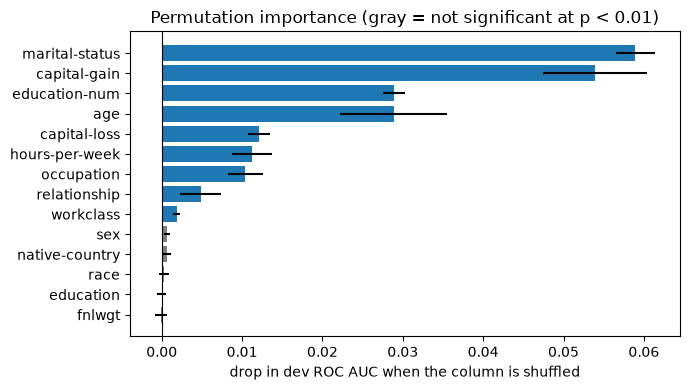

In [12]:
start = time.perf_counter()
fi = stack_pred.feature_importance(dev_df, subsample_size=3000, num_shuffle_sets=5, silent=True)
print(f"computed in {time.perf_counter() - start:.0f} s")
print(fi.round(4).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ordered = fi.sort_values("importance")
ax.barh(ordered.index, ordered["importance"], xerr=ordered["stddev"], color=np.where(ordered["p_value"] < 0.01, "tab:blue", "tab:gray"))
ax.axvline(0, c="black", lw=0.8)
ax.set(xlabel="drop in dev ROC AUC when the column is shuffled", title="Permutation importance (gray = not significant at p < 0.01)")
plt.tight_layout()
plt.show()

Caveats: correlated features share importance (shuffle `education` and the model still has `education-num`), and importance says what the *model* uses, not what *causes* high income.

### ✍️ Your Turn

Which feature makes dev ROC AUC drop the most when it is shuffled? Store its **name** in `top_feature`.

In [13]:
top_feature = None  # TODO: your code here
check("top_feature", top_feature, str(fi["importance"].idxmax()), hint="fi is a DataFrame indexed by feature name: look at the importance column.")

⏳ top_feature: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
top_feature = fi.sort_values("importance", ascending=False).index[0]
check("top_feature", top_feature, str(fi["importance"].idxmax()))
```

Before trusting it, look at its `stddev` and `p_value`, and ask whether the feature would be available at prediction time.
</details>

> 💡 **Interview angle:** "Permutation importance vs built-in tree importance?" — permutation importance is model-agnostic and measured on held-out data in units of the metric; split-count/gain importance is biased toward high-cardinality features and computed on training data. Both are fooled by correlated features.

## 7. Probabilities and Decision Thresholds 🟡

`predict` turns probabilities into labels with a **threshold** (0.5 by default for binary problems). The best threshold depends on the metric and on the cost of mistakes. AutoGluon can choose one on its **internal validation data** (OOF predictions here), so our dev set stays clean for evaluation.

threshold chosen on validation data for F1: 0.358
default 0.5  → dev F1 0.6970 | precision 0.7801 | recall 0.6299 | ROC AUC 0.9230 | predicted positive 19.3%
tuned 0.358  → dev F1 0.7157 | precision 0.6672 | recall 0.7719 | ROC AUC 0.9230 | predicted positive 27.7%


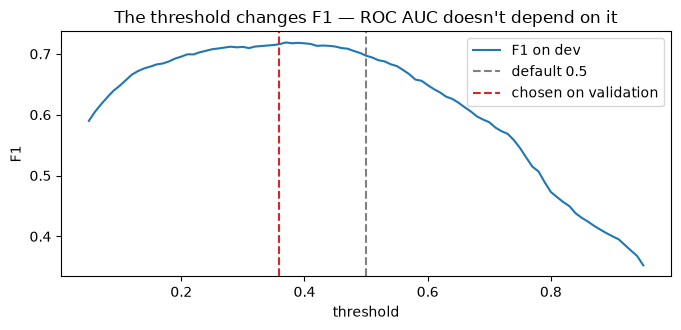

In [14]:
proba_dev = stack_pred.predict_proba(X_dev)[">50K"]
y_dev = (dev_df[LABEL] == ">50K").astype(int)

tuned_threshold = stack_pred.calibrate_decision_threshold(metric="f1", verbose=False)   # uses internal (OOF) validation data
default_eval = stack_pred.evaluate(dev_df, decision_threshold=0.5)
tuned_eval = stack_pred.evaluate(dev_df, decision_threshold=tuned_threshold)
print(f"threshold chosen on validation data for F1: {tuned_threshold:.3f}")
for name, scores, t in [("default 0.5", default_eval, 0.5), (f"tuned {tuned_threshold:.3f}", tuned_eval, tuned_threshold)]:
    print(f"{name:12s} → dev F1 {scores['f1']:.4f} | precision {scores['precision']:.4f} | recall {scores['recall']:.4f} | "
          f"ROC AUC {scores['roc_auc']:.4f} | predicted positive {np.mean(proba_dev >= t):.1%}")

thresholds = np.linspace(0.05, 0.95, 91)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(thresholds, [f1_score(y_dev, proba_dev >= t) for t in thresholds], label="F1 on dev")
ax.axvline(0.5, ls="--", c="gray", label="default 0.5")
ax.axvline(tuned_threshold, ls="--", c="tab:red", label="chosen on validation")
ax.set(xlabel="threshold", ylabel="F1", title="The threshold changes F1 — ROC AUC doesn't depend on it")
ax.legend()
plt.tight_layout()
plt.show()

ROC AUC is identical for both thresholds because it ranks probabilities; F1, precision, and recall depend on where you cut. `predictor.set_decision_threshold(t)` stores the choice so `predict` uses it.

### ✍️ Your Turn

Using `proba_dev` and `y_dev`, compute **recall** (the fraction of true `>50K` people that are predicted positive) at threshold **0.3**. Store it in `recall_at_03`.

In [15]:
recall_at_03 = None  # TODO: your code here
check("recall_at_03", recall_at_03, ((proba_dev >= 0.3) & (y_dev == 1)).sum() / (y_dev == 1).sum(),
      hint="Among rows with y_dev == 1, what fraction has proba_dev >= 0.3?")

⏳ recall_at_03: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
recall_at_03 = (proba_dev[y_dev == 1] >= 0.3).mean()
check("recall_at_03", recall_at_03, ((proba_dev >= 0.3) & (y_dev == 1)).sum() / (y_dev == 1).sum())
```

Lowering the threshold raises recall and lowers precision. Pick the trade-off from business costs, on validation data.
</details>

> 💡 **Interview angle:** "Your model's F1 is poor but AUC is great — what do you try first?" — tune the decision threshold on validation data for the metric (or cost matrix) you care about; the ranking is already good. Also check calibration if downstream code uses probabilities as risks.

## 8. Deployment Trade-offs: refit_full, Clones, Latency, Disk 🔴

The stacked predictor is accurate but heavy: every bagged model is **5 fold models**, and the final ensemble needs all its ancestors. Tools to slim it down:

| Tool | What it does |
|---|---|
| `refit_full(model=...)` | retrain a model (and its ancestors) **once on all training data** → one model instead of k fold models; creates `*_FULL` versions |
| `clone_for_deployment(path, model=...)` | copy only what that model needs to predict into a new folder |
| `persist()` | load models into memory so each `predict` doesn't read from disk |
| `delete_models(models_to_keep=...)` | delete everything else from a predictor |
| preset `optimize_for_deployment` | keep only the best model and drop training artefacts |

Note that `*_FULL` models have **no validation score**: all data was used for training, so evaluate them on held-out data.

In [16]:
start = time.perf_counter()
refit_map = stack_pred.refit_full(model="best", set_best_to_refit_full=False)
single_map = stack_pred.refit_full(model="LightGBM_BAG_L1", set_best_to_refit_full=False)
print(f"refit_full took {time.perf_counter() - start:.0f} s; new models: {sorted(set(refit_map.values()) | set(single_map.values()))}")

best_before = stack_pred.model_best
options = {
    "bagged stack (as trained)": best_before,
    "stack refit on full data": refit_map[best_before],
    "single LightGBM (refit)": single_map["LightGBM_BAG_L1"],
}
one_row, batch = X_dev.head(1), X_dev.head(1000)
deploy_rows = []
for label, model_name in options.items():
    clone_path = OUTPUT_DIR / "deploy" / model_name
    shutil.rmtree(clone_path, ignore_errors=True)
    # Workaround for AutoGluon 1.6.1: once *_FULL models exist, clone_for_deployment(model=X) crashes unless X is
    # the saved "best" model, so we make X the best model on disk first (and restore the original after the loop).
    stack_pred.set_model_best(model_name, save_trainer=True)
    clone = stack_pred.clone_for_deployment(str(clone_path), model=model_name, return_clone=True)
    clone.persist()
    clone.predict(one_row)                                                  # warm-up
    t0 = time.perf_counter()
    for _ in range(30):
        clone.predict(one_row)
    single_ms = (time.perf_counter() - t0) / 30 * 1000
    t0 = time.perf_counter()
    clone.predict_proba(batch)
    batch_ms = (time.perf_counter() - t0) * 1000
    n_models = len(clone.model_names())
    deploy_rows.append({"option": label, "model": model_name, "models on disk": n_models,
                        "disk MB": round(dir_size_mb(clone_path), 1), "1-row latency ms": round(single_ms, 1),
                        "1000-row batch ms": round(batch_ms, 1), "dev AUC": round(clone.evaluate(dev_df)["roc_auc"], 4)})
    clone.unpersist()
stack_pred.set_model_best(best_before, save_trainer=True)                  # back to the accuracy-best model
deploy = pd.DataFrame(deploy_rows).set_index("option")
print(deploy.to_string())
full_stack, light = deploy.iloc[0], deploy.iloc[2]
print(f"\nsingle LightGBM vs bagged stack: {full_stack['1-row latency ms'] / light['1-row latency ms']:.1f}× faster per row, "
      f"{full_stack['disk MB'] / light['disk MB']:.0f}× smaller, dev AUC {light['dev AUC'] - full_stack['dev AUC']:+.4f}")

refit_full took 3 s; new models: ['ExtraTrees_BAG_L1_FULL', 'ExtraTrees_BAG_L2_FULL', 'LightGBM_BAG_L1_FULL', 'LightGBM_BAG_L2_FULL', 'RandomForest_BAG_L1_FULL', 'RandomForest_BAG_L2_FULL', 'WeightedEnsemble_L3_FULL', 'XGBoost_BAG_L1_FULL']


                                              model  models on disk  disk MB  1-row latency ms  1000-row batch ms  dev AUC
option                                                                                                                    
bagged stack (as trained)       WeightedEnsemble_L3               8    219.2              78.5               98.8   0.9230
stack refit on full data   WeightedEnsemble_L3_FULL               8    211.9              65.8               72.4   0.9224
single LightGBM (refit)        LightGBM_BAG_L1_FULL               1      0.5               1.5                2.4   0.9194

single LightGBM vs bagged stack: 52.3× faster per row, 438× smaller, dev AUC -0.0036


Much of the single-row latency is AutoGluon's own feature preprocessing and Python overhead that every option pays; the ensemble cost shows up most in the batch column and on disk. Measure on your serving hardware and batch size — then decide whether the extra AUC is worth it.

### ✍️ Your Turn

From the `deploy` table, compute **how many rows per second** the refit stack can score in batch mode (1000 rows ÷ batch seconds). Store it in `stack_rows_per_second`.

In [17]:
stack_rows_per_second = None  # TODO: your code here
check("stack_rows_per_second", stack_rows_per_second, 1000 / (deploy.loc["stack refit on full data", "1000-row batch ms"] / 1000),
      hint="batch ms / 1000 = seconds for 1000 rows")

⏳ stack_rows_per_second: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
stack_rows_per_second = 1000 / (deploy.loc["stack refit on full data", "1000-row batch ms"] / 1000)
check("stack_rows_per_second", stack_rows_per_second, 1000 / (deploy.loc["stack refit on full data", "1000-row batch ms"] / 1000))
```
</details>

> 💡 **Interview angle:** "Would you ship this 20-model ensemble?" — only if the accuracy gain is worth its measured latency, memory, and operational cost. Options: `refit_full` (one model per base learner), distil into a single model, keep the best single model, or use the ensemble for offline/batch scoring only.

## 9. AutoML as a Baseline vs a Final Model 🟢

| Use AutoML as a **baseline** when… | Use it as the **final model** when… |
|---|---|
| you need to know quickly how much signal the data has | offline/batch scoring where latency and size don't matter |
| you plan to hand-engineer features and want a bar to beat | the team lacks time for manual tuning and the ensemble passes latency/cost checks |
| explainability, monotonic constraints, or tiny models are required later | you can monitor and retrain it like any other model |

A quick sanity table from what we've already trained — every number on the dev set:

In [18]:
default_lgb = lgb.LGBMClassifier(verbose=-1, random_state=SEED, n_jobs=NUM_CPUS).fit(train_small.drop(columns=LABEL), y_small)
baseline_table = pd.Series({
    "always predict the base rate": 0.5,
    "LightGBM with default settings": roc_auc_score(y_dev, default_lgb.predict_proba(X_dev)[:, 1]),
    "AutoGluon medium_quality (60 s)": predictor.evaluate(dev_df)["roc_auc"],
    "AutoGluon bagged + stacked": stack_pred.evaluate(dev_df)["roc_auc"],
}, name="dev ROC AUC").round(4)
print(baseline_table.to_string())
headroom = baseline_table["AutoGluon bagged + stacked"] - baseline_table["LightGBM with default settings"]
print(f"\nheadroom of the heavy AutoML ensemble over one default LightGBM on 10k rows: {headroom:+.4f} AUC")

always predict the base rate       0.5000
LightGBM with default settings     0.9194
AutoGluon medium_quality (60 s)    0.9208
AutoGluon bagged + stacked         0.9230

headroom of the heavy AutoML ensemble over one default LightGBM on 10k rows: +0.0036 AUC


If AutoML barely beats a default gradient-boosting model, the remaining gains will come from **better data and features**, not from more model search. If the gap is large, it's worth tuning (or shipping a slimmed ensemble).

> 💡 **Interview angle:** "AutoML beat your hand-built model — now what?" — check both use the same split and no leakage; look at the leaderboard and feature importance to learn *why* (a model family you didn't try, stacking, better categorical handling); then decide on latency, cost, and maintainability, not on the metric alone.

## 🔧 Build It From Scratch

A **2-level stacking ensemble** with out-of-fold predictions, using only scikit-learn and LightGBM:

1. Split `train_small` into 5 stratified folds. For each fold and each base model (LightGBM, random forest, logistic regression), train on the other 4 folds and predict the held-out fold → an OOF matrix `(n_rows, 3)`.
2. **Assert no leakage:** record which fold produced each row's prediction and check that row wasn't in that model's training indices.
3. Train a logistic-regression **meta-learner** on the OOF matrix.
4. Refit each base model on all rows; at prediction time feed their probabilities to the meta-learner.
5. Check against `sklearn.ensemble.StackingClassifier` (same folds) — identical meta-learner — and compare with AutoGluon's stack on dev.

In [19]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

categorical = make_column_selector(dtype_include="category")
numeric = make_column_selector(dtype_exclude="category")
BASE_MODELS = {
    "lightgbm": lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, verbose=-1, random_state=SEED,
                                   n_jobs=NUM_CPUS, deterministic=True, force_row_wise=True),
    "random_forest": make_pipeline(
        ColumnTransformer([("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical)], remainder="passthrough"),
        RandomForestClassifier(n_estimators=200, min_samples_leaf=3, random_state=SEED, n_jobs=NUM_CPUS)),
    "logistic": make_pipeline(
        ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), categorical), ("num", StandardScaler(), numeric)]),
        LogisticRegression(max_iter=2000)),
}
X_small = train_small.drop(columns=LABEL)
y_small_np = y_small.to_numpy()
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

start = time.perf_counter()
oof = np.zeros((len(X_small), len(BASE_MODELS)))
produced_by_fold = np.full(len(X_small), -1)
train_indices_of_fold = []
for fold_id, (fit_idx, holdout_idx) in enumerate(folds.split(X_small, y_small_np)):
    train_indices_of_fold.append(set(fit_idx.tolist()))
    produced_by_fold[holdout_idx] = fold_id
    for j, base in enumerate(BASE_MODELS.values()):
        fold_model = clone(base).fit(X_small.iloc[fit_idx], y_small_np[fit_idx])
        oof[holdout_idx, j] = fold_model.predict_proba(X_small.iloc[holdout_idx])[:, 1]

leaks = sum(row in train_indices_of_fold[produced_by_fold[row]] for row in range(len(X_small)))
assert (produced_by_fold >= 0).all() and leaks == 0
print(f"✅ all {len(X_small):,} rows have an OOF prediction, and {leaks} of them came from a model trained on that row")

meta = LogisticRegression().fit(oof, y_small_np)
full_bases = {name: clone(base).fit(X_small, y_small_np) for name, base in BASE_MODELS.items()}
dev_meta_features = np.column_stack([m.predict_proba(X_dev)[:, 1] for m in full_bases.values()])
our_stack_proba = meta.predict_proba(dev_meta_features)[:, 1]
print(f"built in {time.perf_counter() - start:.0f} s | meta-learner weights {dict(zip(BASE_MODELS, meta.coef_[0].round(3)))}")

✅ all 10,000 rows have an OOF prediction, and 0 of them came from a model trained on that row


built in 5 s | meta-learner weights {'lightgbm': np.float64(3.281), 'random_forest': np.float64(2.186), 'logistic': np.float64(1.109)}


In [20]:
sk_stack = StackingClassifier(estimators=list(BASE_MODELS.items()), final_estimator=LogisticRegression(), cv=folds,
                              stack_method="predict_proba").fit(X_small, y_small_np)
assert np.allclose(sk_stack.final_estimator_.coef_, meta.coef_, atol=1e-6)
assert np.allclose(sk_stack.predict_proba(X_dev)[:, 1], our_stack_proba, atol=1e-6)
print("✅ identical to scikit-learn's StackingClassifier (meta-learner coefficients and dev probabilities)")

comparison = pd.Series({
    **{f"{name} alone": roc_auc_score(y_dev, dev_meta_features[:, j]) for j, name in enumerate(BASE_MODELS)},
    "our 2-level stack": roc_auc_score(y_dev, our_stack_proba),
    f"AutoGluon stack ({stack_pred.model_best})": stack_board.set_index("model").loc[stack_pred.model_best, "score_test"],
}, name="dev ROC AUC").round(4)
print(comparison.to_string())
best_base = max(BASE_MODELS, key=lambda name: comparison[f"{name} alone"])
if comparison["our 2-level stack"] > comparison[f"{best_base} alone"]:
    print(f"→ our stack beat its best base model ({best_base}) on dev")
else:
    print(f"→ our stack did NOT beat its best base model ({best_base}) on dev: with 3 base models of which one dominates, "
          "stacking has little to combine — diversity and more models are what make AutoGluon's stack pay off")

✅ identical to scikit-learn's StackingClassifier (meta-learner coefficients and dev probabilities)
lightgbm alone                           0.9193
random_forest alone                      0.9096
logistic alone                           0.9034
our 2-level stack                        0.9184
AutoGluon stack (WeightedEnsemble_L3)    0.9230
→ our stack did NOT beat its best base model (lightgbm) on dev: with 3 base models of which one dominates, stacking has little to combine — diversity and more models are what make AutoGluon's stack pay off


AutoGluon's version adds more (and more diverse) base models, a second bagged layer that also sees the original features, averaging of fold models instead of a single refit, and greedy ensemble weights — but the leakage-free core is exactly these 20 lines.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — ID and ordering leakage

Imagine the data export was **sorted by outcome** before row IDs were assigned. The ID now encodes the label. Any model — AutoML included — will happily use it. We show it with a quick LightGBM.

In [21]:
leaky = train_small.sort_values(LABEL).reset_index(drop=True)
leaky["row_id"] = np.arange(len(leaky))                                    # IDs assigned after sorting by the label
y_leaky = (leaky[LABEL] == ">50K").astype(int)
fit_part, check_part = train_test_split(leaky, test_size=0.3, stratify=y_leaky, random_state=SEED)
id_model = lgb.LGBMClassifier(n_estimators=200, verbose=-1, random_state=SEED, n_jobs=NUM_CPUS)
id_model.fit(fit_part.drop(columns=LABEL), (fit_part[LABEL] == ">50K").astype(int))
auc_random_split = roc_auc_score(check_part[LABEL] == ">50K", id_model.predict_proba(check_part.drop(columns=LABEL))[:, 1])

new_rows = dev_df.assign(row_id=np.arange(len(dev_df)) + len(leaky))       # tomorrow's rows get new, unrelated IDs
auc_new_rows = roc_auc_score(y_dev, id_model.predict_proba(new_rows.drop(columns=LABEL))[:, 1])
print(f"❌ with row_id: random-split AUC {auc_random_split:.4f} (looks amazing) → AUC on new rows {auc_new_rows:.4f}")

clean_model = lgb.LGBMClassifier(n_estimators=200, verbose=-1, random_state=SEED, n_jobs=NUM_CPUS)
clean_model.fit(fit_part.drop(columns=[LABEL, "row_id"]), (fit_part[LABEL] == ">50K").astype(int))
print(f"✅ drop identifiers  : AUC on new rows {roc_auc_score(y_dev, clean_model.predict_proba(X_dev)[:, 1]):.4f}")

❌ with row_id: random-split AUC 1.0000 (looks amazing) → AUC on new rows 0.7234


✅ drop identifiers  : AUC on new rows 0.9140


### ❌ Pitfall 2 — Using the wrong probability column

`predict_proba` has one column per class. Scoring the negative-class column flips every ranking.

In [22]:
all_proba = predictor.predict_proba(X_dev)
print("columns:", list(all_proba.columns), "| positive class:", predictor.positive_class)
print(f"❌ AUC using column 0 ('{all_proba.columns[0]}'): {roc_auc_score(y_dev, all_proba.iloc[:, 0]):.4f}")
print(f"✅ AUC using predictor.positive_class        : {roc_auc_score(y_dev, all_proba[predictor.positive_class]):.4f}")

columns: ['<=50K', '>50K'] | positive class: >50K
❌ AUC using column 0 ('<=50K'): 0.0792
✅ AUC using predictor.positive_class        : 0.9208


### ❌ Pitfall 3 — Stacking on in-sample predictions

Feed the meta-learner predictions that base models made **on their own training rows**. The random forest nearly memorises the training data, so the meta-learner learns to trust it far too much.

In [23]:
in_sample_features = np.column_stack([m.predict_proba(X_small)[:, 1] for m in full_bases.values()])   # ❌ same rows the bases trained on
leaky_meta = LogisticRegression().fit(in_sample_features, y_small_np)
print("❌ in-sample meta weights:", dict(zip(BASE_MODELS, leaky_meta.coef_[0].round(2))),
      f"→ dev AUC {roc_auc_score(y_dev, leaky_meta.predict_proba(dev_meta_features)[:, 1]):.4f}")
print("✅ out-of-fold meta weights:", dict(zip(BASE_MODELS, meta.coef_[0].round(2))),
      f"→ dev AUC {roc_auc_score(y_dev, our_stack_proba):.4f}")
print(f"random forest's in-sample AUC {roc_auc_score(y_small_np, in_sample_features[:, 1]):.4f} vs out-of-fold AUC {roc_auc_score(y_small_np, oof[:, 1]):.4f}")

❌ in-sample meta weights: {'lightgbm': np.float64(8.69), 'random_forest': np.float64(11.38), 'logistic': np.float64(-9.72)} → dev AUC 0.8941
✅ out-of-fold meta weights: {'lightgbm': np.float64(3.28), 'random_forest': np.float64(2.19), 'logistic': np.float64(1.11)} → dev AUC 0.9184
random forest's in-sample AUC 0.9768 vs out-of-fold AUC 0.9099


### ❌ Pitfall 4 — Reporting the ensemble's `score_val` as expected performance

In the quick-start predictor (Section 2), AutoGluon ranked 10 models **and** fitted the ensemble weights on the same 1,000-row holdout it then reports `score_val` on. Compare those validation scores with our held-out dev scores:

In [24]:
def validation_optimism(leaderboard, best_model):
    gaps = leaderboard.assign(gap=leaderboard["score_val"] - leaderboard["score_test"]).set_index("model")
    return gaps.loc[best_model, "score_val"], gaps.loc[best_model, "score_test"], gaps.loc[best_model, "gap"], gaps.loc[gaps["stack_level"] == 1, "gap"].mean()


for label, lb, best_model in [("holdout validation (quick start, 1,000 rows)", board, predictor.model_best),
                              ("out-of-fold validation (bagged, 10,000 rows)", stack_board, stack_pred.model_best)]:
    val, dev, ens_gap, single_gap = validation_optimism(lb, best_model)
    flag = "❌" if ens_gap > 0 else "✅"
    print(f"{flag} {label}: {best_model} score_val {val:.4f} vs dev {dev:.4f} → optimism {ens_gap:+.4f} "
          f"(single models average {single_gap:+.4f})")
print("✅ report the number from data no model or ensemble weight ever saw — a test set used once (see the mini project)")

❌ holdout validation (quick start, 1,000 rows): WeightedEnsemble_L2 score_val 0.9266 vs dev 0.9208 → optimism +0.0058 (single models average +0.0030)
✅ out-of-fold validation (bagged, 10,000 rows): WeightedEnsemble_L3 score_val 0.9224 vs dev 0.9230 → optimism -0.0006 (single models average -0.0029)
✅ report the number from data no model or ensemble weight ever saw — a test set used once (see the mini project)


A small holdout makes `score_val` noisy and the selected ensemble looks better than it is; out-of-fold validation over all training rows is far more reliable — one more reason bagging is worth its cost. Either way, the number you report comes from untouched data.

## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Count the layer-1 models
How many models in `stack_board` (Section 5) are on **stack level 1**? Store it in `n_layer1`.

In [25]:
n_layer1 = None  # TODO
check("n_layer1", n_layer1, len([m for m in stack_board["model"] if m.endswith("_L1")]), hint="(stack_board['stack_level'] == 1).sum()")

⏳ n_layer1: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_layer1 = int((stack_board["stack_level"] == 1).sum())
check("n_layer1", n_layer1, len([m for m in stack_board["model"] if m.endswith("_L1")]))
```
</details>

### 🟢 Exercise 2 — Probabilities to labels
Using `predictor.predict_proba(X_dev)`, count the dev rows whose probability of `>50K` is **at least 0.5**. Store it in `n_predicted_positive`; it should equal the number of `>50K` labels from `predictor.predict`.

In [26]:
n_predicted_positive = None  # TODO
check("n_predicted_positive", n_predicted_positive, int((predictor.predict(X_dev) == ">50K").sum()),
      hint="(predictor.predict_proba(X_dev)[predictor.positive_class] >= 0.5).sum()")

⏳ n_predicted_positive: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_predicted_positive = int((predictor.predict_proba(X_dev)[predictor.positive_class] >= 0.5).sum())
check("n_predicted_positive", n_predicted_positive, int((predictor.predict(X_dev) == ">50K").sum()))
```
</details>

### 🟢 Exercise 3 — Significant features
From the permutation-importance table `fi` (Section 6), count the features with `p_value < 0.01` **and** positive importance. Store it in `n_significant`.

In [27]:
n_significant = None  # TODO
check("n_significant", n_significant, len(fi.query("p_value < 0.01 and importance > 0")), hint="Combine two boolean masks with &.")

⏳ n_significant: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_significant = int(((fi["p_value"] < 0.01) & (fi["importance"] > 0)).sum())
check("n_significant", n_significant, len(fi.query("p_value < 0.01 and importance > 0")))
```
</details>

### 🟡 Exercise 4 — Out-of-fold predictions for one model
Write `oof_predict(model, X, y, folds)` that returns, for every row, the positive-class probability from a clone of `model` trained on the **other** folds. It must match `cross_val_predict`.

In [28]:
def oof_predict(model, X, y, folds):
    return None  # TODO


_lr_model = BASE_MODELS["logistic"]
_got = oof_predict(_lr_model, X_small, y_small_np, folds)
check("oof_predict", _got, cross_val_predict(_lr_model, X_small, y_small_np, cv=folds, method="predict_proba")[:, 1],
      hint="Loop over folds.split(X, y); fit clone(model) on the fit rows; fill predictions for the held-out rows.")

⏳ oof_predict: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def oof_predict(model, X, y, folds):
    predictions = np.zeros(len(X))
    for fit_idx, holdout_idx in folds.split(X, y):
        fold_model = clone(model).fit(X.iloc[fit_idx], y[fit_idx])
        predictions[holdout_idx] = fold_model.predict_proba(X.iloc[holdout_idx])[:, 1]
    return predictions


_lr_model = BASE_MODELS["logistic"]
check("oof_predict", oof_predict(_lr_model, X_small, y_small_np, folds),
      cross_val_predict(_lr_model, X_small, y_small_np, cv=folds, method="predict_proba")[:, 1])
```
</details>

### 🟡 Exercise 5 — Pick a threshold for F1
Write `best_f1_threshold(y_true, proba, thresholds)` returning `(threshold, f1)` for the threshold with the highest F1 (predict positive when `proba >= threshold`; ties → the first threshold).

In [29]:
def best_f1_threshold(y_true, proba, thresholds):
    return None  # TODO


_result = best_f1_threshold(np.array([0, 0, 1, 1, 1, 0, 1, 0]), np.array([0.1, 0.4, 0.35, 0.8, 0.65, 0.3, 0.55, 0.7]), [0.3, 0.5, 0.7])
check("best_f1_threshold", _result, [0.5, 0.75], hint="Compute f1_score(y_true, proba >= t) for each t and keep the argmax.")

⏳ best_f1_threshold: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def best_f1_threshold(y_true, proba, thresholds):
    scores = [f1_score(y_true, proba >= t) for t in thresholds]
    best = int(np.argmax(scores))
    return thresholds[best], scores[best]


_result = best_f1_threshold(np.array([0, 0, 1, 1, 1, 0, 1, 0]), np.array([0.1, 0.4, 0.35, 0.8, 0.65, 0.3, 0.55, 0.7]), [0.3, 0.5, 0.7])
check("best_f1_threshold", _result, [0.5, 0.75])
```
At 0.3: TP 4, FP 3 → F1 0.727. At 0.5: TP 3, FP 1, FN 1 → F1 0.75. At 0.7: TP 1, FP 1, FN 3 → F1 0.333. Choose thresholds on validation data, never on the test set.
</details>

### 🔴 Exercise 6 — Greedy ensemble selection (how `WeightedEnsemble` works)
Caruana et al. (2004): start with an empty ensemble; for `n_iterations` steps, add (with replacement) the model whose inclusion gives the **lowest log loss** of the averaged predictions; ties → lowest model index. Weights = how often each model was picked ÷ `n_iterations`. Implement `greedy_ensemble(probs, y, n_iterations)` where `probs` has shape `(n_models, n_rows)`.

In [30]:
def greedy_ensemble(probs, y, n_iterations):
    return None  # TODO


_y = [1, 1, 1, 1, 0, 0, 0, 0]
_probs = [[0.9, 0.8, 0.3, 0.4, 0.2, 0.1, 0.6, 0.7],       # model 0: good on the first half
          [0.4, 0.3, 0.9, 0.8, 0.6, 0.7, 0.2, 0.1],       # model 1: good on the second half
          [0.5] * 8]                                        # model 2: always unsure
check("greedy_ensemble", greedy_ensemble(_probs, _y, 5), [0.6, 0.4, 0.0],
      hint="Keep a running average; at step i try (current·i + probs[m]) / (i + 1) for every m.")

⏳ greedy_ensemble: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def greedy_ensemble(probs, y, n_iterations):
    probs, y = np.asarray(probs, dtype=float), np.asarray(y, dtype=float)
    counts, current = np.zeros(len(probs)), np.zeros(probs.shape[1])

    def log_loss(p):
        p = np.clip(p, 1e-15, 1 - 1e-15)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    for i in range(n_iterations):
        losses = [log_loss((current * i + probs[m]) / (i + 1)) for m in range(len(probs))]
        best = int(np.argmin(losses))                      # argmin returns the first index on ties
        counts[best] += 1
        current = (current * i + probs[best]) / (i + 1)
    return counts / n_iterations


_y = [1, 1, 1, 1, 0, 0, 0, 0]
_probs = [[0.9, 0.8, 0.3, 0.4, 0.2, 0.1, 0.6, 0.7], [0.4, 0.3, 0.9, 0.8, 0.6, 0.7, 0.2, 0.1], [0.5] * 8]
check("greedy_ensemble", greedy_ensemble(_probs, _y, 5), [0.6, 0.4, 0.0])
```
Models 0 and 1 make opposite mistakes, so averaging them beats either alone; the "always unsure" model never helps. Selection with replacement lets weights be non-uniform, and fitting weights on OOF predictions keeps it leakage-free.
</details>

## 🚀 Mini Project: AutoGluon vs a Hand-Tuned LightGBM on Adult Income

**Goal:** under a fixed budget, does AutoGluon beat a carefully tuned single LightGBM — and what does it cost in latency and disk?

**Rules:** both approaches use exactly the same data: **train + dev (80%)** for everything they do, and the **test set (20%) once** at the end.
- **LightGBM:** random search over 12 configs, each trained on *train* with early stopping on *dev*; then refit the best config on train + dev for its best number of rounds.
- **AutoGluon:** `medium_quality`, `time_limit=120`, 4 CPUs, on train + dev (it carves its own internal validation split).

### Step 1 — Hand-tuned LightGBM

In [31]:
y_train_np = (train_df[LABEL] == ">50K").astype(int)
X_train_df = train_df.drop(columns=LABEL)
search_rng = np.random.default_rng(SEED)
trials = []
start = time.perf_counter()
for trial in range(12):
    # fresh Datasets per trial: LightGBM bins features once per Dataset, and min_child_samples changes that binning
    train_set = lgb.Dataset(X_train_df, y_train_np)
    dev_set = lgb.Dataset(X_dev, y_dev, reference=train_set)
    params = {"objective": "binary", "metric": "auc", "verbosity": -1, "num_threads": NUM_CPUS, "seed": SEED,
              "learning_rate": float(10 ** search_rng.uniform(-1.7, -0.8)), "num_leaves": int(search_rng.integers(8, 128)),
              "min_child_samples": int(search_rng.integers(5, 100)), "feature_fraction": float(search_rng.uniform(0.5, 1.0)),
              "bagging_fraction": float(search_rng.uniform(0.5, 1.0)), "bagging_freq": 1, "lambda_l2": float(10 ** search_rng.uniform(-3, 1))}
    booster = lgb.train(params, train_set, num_boost_round=3000, valid_sets=[dev_set], valid_names=["dev"],
                        callbacks=[lgb.early_stopping(100, verbose=False)])
    trials.append({**params, "dev_auc": booster.best_score["dev"]["auc"], "rounds": booster.best_iteration})
lgb_search_seconds = time.perf_counter() - start
search_table = pd.DataFrame(trials).sort_values("dev_auc", ascending=False)
print(f"12 configs in {lgb_search_seconds:.0f} s")
print(search_table[["learning_rate", "num_leaves", "min_child_samples", "feature_fraction", "lambda_l2", "rounds", "dev_auc"]].round(4).head(5).to_string(index=False))

best_params = search_table.iloc[0].to_dict()
best_rounds = int(best_params.pop("rounds"))
best_params.pop("dev_auc")
best_params = {k: (int(v) if k in ("num_leaves", "min_child_samples", "bagging_freq", "num_threads", "seed") else v) for k, v in best_params.items()}

full_df = pd.concat([train_df, dev_df])
start = time.perf_counter()
final_lgb = lgb.train(best_params, lgb.Dataset(full_df.drop(columns=LABEL), (full_df[LABEL] == ">50K").astype(int)), num_boost_round=best_rounds)
lgb_refit_seconds = time.perf_counter() - start
print(f"refit on train + dev ({len(full_df):,} rows) for {best_rounds} rounds in {lgb_refit_seconds:.1f} s")

12 configs in 12 s
 learning_rate  num_leaves  min_child_samples  feature_fraction  lambda_l2  rounds  dev_auc
        0.0212           8                 16            0.8353     0.2894    1590   0.9254
        0.0831          92                 41            0.5675     0.1263      96   0.9251
        0.0380          58                 51            0.9447     0.0270     277   0.9246
        0.0652          38                 35            0.7972     0.0369     129   0.9242
        0.0287          18                 87            0.7707     0.0491     445   0.9239


refit on train + dev (39,073 rows) for 1590 rounds in 1.2 s


### Step 2 — AutoGluon under a 2-minute budget

In [32]:
start = time.perf_counter()
ag_final = TabularPredictor(label=LABEL, eval_metric="roc_auc", path=str(OUTPUT_DIR / "project"), verbosity=0).fit(
    full_df, presets="medium_quality", time_limit=120, num_cpus=NUM_CPUS, excluded_model_types=EXCLUDED_MODELS)
ag_seconds = time.perf_counter() - start
print(f"AutoGluon fit in {ag_seconds:.0f} s | best model {ag_final.model_best}")
print(ag_final.leaderboard()[["model", "score_val", "fit_time", "pred_time_val"]].round(4).to_string(index=False))

AutoGluon fit in 14 s | best model WeightedEnsemble_L2
              model  score_val  fit_time  pred_time_val
WeightedEnsemble_L2     0.9332    8.0413         0.0386
           CatBoost     0.9327    7.0401         0.0033
            XGBoost     0.9320    0.4541         0.0037
           LightGBM     0.9300    0.5947         0.0032
      LightGBMLarge     0.9294    1.9055         0.0051
         LightGBMXT     0.9261    1.7347         0.0085
   RandomForestEntr     0.9105    0.5497         0.0387
   RandomForestGini     0.9104    0.5135         0.0313
     ExtraTreesEntr     0.9058    0.3885         0.0440
     ExtraTreesGini     0.9042    0.3633         0.0309


### Step 3 — One evaluation on the test set

LightGBM (hand-tuned)  test ROC AUC 0.9284
AutoGluon              test ROC AUC 0.9295


AutoGluon − LightGBM = +0.0011 AUC, 95% paired bootstrap CI [+0.0002, +0.0021]


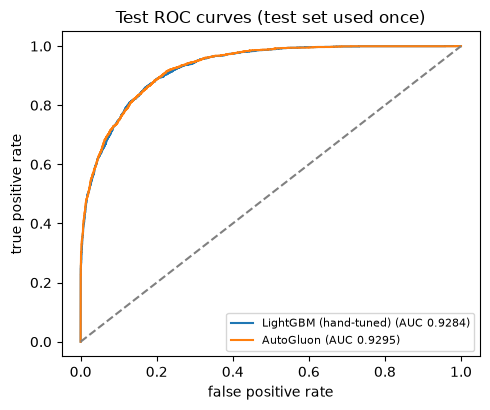

In [33]:
X_test = test_df.drop(columns=LABEL)
y_test = (test_df[LABEL] == ">50K").astype(int).to_numpy()
test_proba = {"LightGBM (hand-tuned)": final_lgb.predict(X_test),
              "AutoGluon": ag_final.predict_proba(X_test)[ag_final.positive_class].to_numpy()}
test_auc = {name: roc_auc_score(y_test, p) for name, p in test_proba.items()}
for name, auc in test_auc.items():
    print(f"{name:22s} test ROC AUC {auc:.4f}")

boot_rng = np.random.default_rng(SEED)
auc_diffs = []
for _ in range(1000):
    idx = boot_rng.integers(0, len(y_test), len(y_test))
    auc_diffs.append(roc_auc_score(y_test[idx], test_proba["AutoGluon"][idx]) - roc_auc_score(y_test[idx], test_proba["LightGBM (hand-tuned)"][idx]))
diff_low, diff_high = np.percentile(auc_diffs, [2.5, 97.5])
auc_gap = test_auc["AutoGluon"] - test_auc["LightGBM (hand-tuned)"]
print(f"AutoGluon − LightGBM = {auc_gap:+.4f} AUC, 95% paired bootstrap CI [{diff_low:+.4f}, {diff_high:+.4f}]")

from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(5, 4.2))
for name, p in test_proba.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, label=f"{name} (AUC {test_auc[name]:.4f})")
ax.plot([0, 1], [0, 1], ls="--", c="gray")
ax.set(xlabel="false positive rate", ylabel="true positive rate", title="Test ROC curves (test set used once)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Step 4 — Latency and disk size

In [34]:
lgb_path = OUTPUT_DIR / "project_lightgbm.txt"
final_lgb.save_model(str(lgb_path))
ag_final.persist()
one_row_test, batch_test = X_test.head(1), X_test.head(1000)


def timed_ms(fn, repeats):
    fn()                                                                      # warm-up
    start = time.perf_counter()
    for _ in range(repeats):
        fn()
    return (time.perf_counter() - start) / repeats * 1000


ag_deploy_path = OUTPUT_DIR / "project_deploy"
ag_final.clone_for_deployment(str(ag_deploy_path))
cost = pd.DataFrame({
    "LightGBM (hand-tuned)": {"1-row latency ms": timed_ms(lambda: final_lgb.predict(one_row_test), 50),
                              "1000-row batch ms": timed_ms(lambda: final_lgb.predict(batch_test), 5),
                              "disk MB (all artefacts)": lgb_path.stat().st_size / 1e6, "disk MB (deployable)": lgb_path.stat().st_size / 1e6},
    "AutoGluon": {"1-row latency ms": timed_ms(lambda: ag_final.predict_proba(one_row_test), 50),
                  "1000-row batch ms": timed_ms(lambda: ag_final.predict_proba(batch_test), 5),
                  "disk MB (all artefacts)": dir_size_mb(ag_final.path), "disk MB (deployable)": dir_size_mb(ag_deploy_path)},
}).T.round(2)
cost["test ROC AUC"] = [round(test_auc[name], 4) for name in cost.index]
print(cost.to_string())
ag_final.unpersist()

                       1-row latency ms  1000-row batch ms  disk MB (all artefacts)  disk MB (deployable)  test ROC AUC
LightGBM (hand-tuned)              0.62               6.00                     1.63                  1.63        0.9284
AutoGluon                         20.03              36.83                  1316.84                257.94        0.9295


['XGBoost', 'WeightedEnsemble_L2', 'CatBoost', 'RandomForestGini']

### Step 5 — Conclusions computed from the numbers

In [35]:
if diff_low > 0:
    quality = f"AutoGluon is significantly better on test (+{auc_gap:.4f} AUC)"
elif diff_high < 0:
    quality = f"the hand-tuned LightGBM is significantly better on test ({auc_gap:+.4f} AUC for AutoGluon)"
else:
    quality = f"the two are statistically indistinguishable on test (difference {auc_gap:+.4f}, CI includes 0)"
latency_ratio = cost.loc["AutoGluon", "1-row latency ms"] / cost.loc["LightGBM (hand-tuned)", "1-row latency ms"]
size_ratio = cost.loc["AutoGluon", "disk MB (deployable)"] / cost.loc["LightGBM (hand-tuned)", "disk MB (deployable)"]
print(f"• Quality: {quality}.")
print(f"• Effort: LightGBM search + refit took {lgb_search_seconds + lgb_refit_seconds:.0f} s of compute plus the code above; "
      f"AutoGluon took {ag_seconds:.0f} s and three lines.")
print(f"• Cost to serve: AutoGluon is {latency_ratio:.0f}× slower per single row and its deployable folder is {size_ratio:.0f}× larger.")
if diff_low > 0 and auc_gap < 0.005:
    print(f"• Decision: the gain is statistically significant but tiny ({auc_gap:+.4f} AUC). For a latency-sensitive API ship the "
          "single LightGBM; AutoGluon is reasonable for offline batch scoring where its cost doesn't matter.")
elif diff_low > 0:
    print("• Decision: worth considering AutoGluon (or a refit/distilled version) if the AUC gain matters more than latency.")
else:
    print("• Decision: ship the single LightGBM — AutoGluon's extra complexity doesn't buy a significant AUC gain here; "
          "it still earned its keep by confirming the tuned model is close to what a heavy ensemble can reach.")

• Quality: AutoGluon is significantly better on test (+0.0011 AUC).
• Effort: LightGBM search + refit took 13 s of compute plus the code above; AutoGluon took 14 s and three lines.
• Cost to serve: AutoGluon is 32× slower per single row and its deployable folder is 158× larger.
• Decision: the gain is statistically significant but tiny (+0.0011 AUC). For a latency-sensitive API ship the single LightGBM; AutoGluon is reasonable for offline batch scoring where its cost doesn't matter.


**Stretch goals**
1. Give AutoGluon `presets="best_quality"` and `time_limit=900` (bagging + stacking on all data). Does the CI move? What happens to latency after `refit_full`?
2. Replace the random LightGBM search with Optuna (previous notebooks) and 50 trials.
3. Use `fit(..., infer_limit=0.002, infer_limit_batch_size=1)` to ask AutoGluon for models that predict one row in ≤ 2 ms, and compare test AUC.
4. Group the data by a feature such as `native-country` and evaluate on unseen groups — is either approach more robust?

### 🗣️ How to talk about this in an interview
- "I benchmarked AutoGluon against a tuned LightGBM on Adult income with identical train/dev/test splits and a single final test evaluation."
- "I compared test ROC AUC with a paired bootstrap confidence interval rather than a single point estimate."
- "Beyond accuracy I measured single-row latency, batch throughput and deployable size, because an ensemble can cost an order of magnitude more to serve."
- "I used AutoML as a ceiling estimate: if a heavy ensemble can't significantly beat one boosted model, remaining gains must come from data and features."
- "I know how AutoGluon avoids stacking leakage — out-of-fold predictions from k-fold bagging — and I rebuilt that in scikit-learn to verify it."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What does AutoML automate, and what does it not?**

<details><summary>Show answer</summary>

- **30-second answer:** It automates model selection, hyperparameters, basic preprocessing, and ensembling under a time budget. It doesn't frame the problem, choose the business metric or threshold, design a leak-free split, engineer domain features, or handle deployment and monitoring.
- **Go deeper:** AutoML will exploit leaks (IDs, post-outcome columns) as eagerly as real signal (Pitfall 1). Its validation score is only as trustworthy as the split you gave it.
- **❌ Common wrong answer:** "AutoML replaces the data scientist."

</details>

**Q2. How does stacking avoid leakage?**

<details><summary>Show answer</summary>

- **30-second answer:** The meta-model trains on out-of-fold predictions: with k-fold bagging each base model predicts only rows it didn't train on, so the meta-features look like predictions on new data.
- **Go deeper:** In-sample meta-features make overfit models (e.g. random forests) look perfect, and the meta-learner over-trusts them — Pitfall 3 measured the resulting drop in held-out AUC. At inference, average the fold models or refit bases on all data.
- **❌ Common wrong answer:** "Use a separate holdout for the meta-model" is valid but wastes data; "just regularise the meta-model" doesn't fix the leak.

</details>

**Q3. Bagging vs boosting vs stacking?**

<details><summary>Show answer</summary>

- **30-second answer:** Bagging trains copies on resampled/partitioned data and averages them (reduces variance). Boosting trains models sequentially, each correcting the previous one's errors (reduces bias). Stacking trains a meta-model to combine different models' predictions.
- **Go deeper:** AutoGluon's "bagging" is k-fold partitioning (not bootstrap), used mainly to produce OOF predictions for stacking; its base models are often boosted trees; the final weighted ensemble is a constrained stacker.
- **❌ Common wrong answer:** "Stacking is the same as averaging models."

</details>

**Q4. What does AutoGluon's WeightedEnsemble do?**

<details><summary>Show answer</summary>

- **30-second answer:** Caruana-style greedy ensemble selection: repeatedly add (with replacement) the model that most improves the validation metric of the averaged predictions; the pick counts become weights.
- **Go deeper:** It's fitted on OOF (or holdout) predictions, so weights are leakage-free, but its own `score_val` is slightly optimistic. Weights are non-negative and sparse, which is more robust than an unconstrained linear stacker. Exercise 6 implements it.
- **❌ Common wrong answer:** "It averages all models equally."

</details>

**Q5. What does `refit_full` do, and why do `_FULL` models have no validation score?**

<details><summary>Show answer</summary>

- **30-second answer:** It retrains each chosen model once on all training data (instead of k fold models), which cuts inference time and size. Since no data was held out, there's nothing left to validate on — evaluate on a separate test set.
- **Go deeper:** The refit model uses the hyperparameters and iteration counts learned during bagging. Section 8 measured latency, disk and dev AUC for bagged vs refit vs single-model options.
- **❌ Common wrong answer:** "`refit_full` makes the model more accurate on validation data."

</details>

**Q6. What do presets and `time_limit` trade off?**

<details><summary>Show answer</summary>

- **30-second answer:** Accuracy vs training time and inference cost. `medium_quality` skips bagging/stacking; `high`/`best_quality` enable bagging, stacking, larger model portfolios, and dynamic stacking to detect stacked overfitting. With a short `time_limit`, later models in the priority list are simply skipped.
- **Go deeper:** Section 3 printed the real preset definitions and showed a 10-second budget training fewer models. Always cap `num_cpus`/`memory_limit` on shared machines.
- **❌ Common wrong answer:** "`best_quality` is always the right choice."

</details>

### 💻 Coding

**Q7. Implement 2-level stacking with out-of-fold predictions in scikit-learn.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  oof = np.column_stack([cross_val_predict(m, X, y, cv=folds, method="predict_proba")[:, 1] for m in bases])
  meta = LogisticRegression().fit(oof, y)
  fitted = [clone(m).fit(X, y) for m in bases]
  proba = meta.predict_proba(np.column_stack([m.predict_proba(X_new)[:, 1] for m in fitted]))[:, 1]
  ```
  Or simply `StackingClassifier(estimators, final_estimator=LogisticRegression(), cv=folds, stack_method="predict_proba")`.
- **Go deeper:** Use stratified (or grouped/time-based) folds consistent with your validation design; pass original features to the meta-model with `passthrough=True` if needed.
- **❌ Common wrong answer:** Fitting bases on all data and using their training-set predictions as meta-features.

</details>

**Q8. How would you deploy an AutoGluon predictor behind a low-latency API?**

<details><summary>Show answer</summary>

- **30-second answer:** Pick a model that meets the latency budget (leaderboard `pred_time`, or `infer_limit` at fit time), `refit_full` it, `clone_for_deployment` to a slim folder, load once at startup with `persist()`, and measure p50/p99 latency on production-like batches.
- **Go deeper:** Pin the AutoGluon version in the serving image (predictors aren't guaranteed to load across versions), validate the input schema, and consider a single exported model (LightGBM) if the ensemble's gain is small.
- **❌ Common wrong answer:** "Load the predictor from disk inside every request."

</details>

### 🐛 Debugging Scenarios

**Q9. AutoML's validation AUC is 0.95, but in production the model scores 0.80. What do you investigate?**

<details><summary>Show answer</summary>

- **30-second answer:** Leakage (IDs, timestamps, post-outcome features), a split that doesn't match production (random split for time-ordered data, same customers in train and validation), optimistic selection over many models, and distribution drift since training.
- **Go deeper:** Re-evaluate with a time- or group-based split, check feature importance for suspicious top features, compare feature distributions between training and live data, and keep a truly untouched test set.
- **❌ Common wrong answer:** "Train longer with `best_quality`."

</details>

**Q10. `customer_id` shows up as the most important feature. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Almost certainly leakage: IDs correlate with the label through how data was collected or sorted (Pitfall 1), or the same customers appear in train and validation. Drop identifiers and use group-aware splits.
- **Go deeper:** Legit exceptions are rare (IDs encoding signup date, for instance) — then engineer that meaning explicitly (tenure) instead of feeding the raw ID.
- **❌ Common wrong answer:** "Great, the ID is predictive — keep it."

</details>

**Q11. An AutoGluon fit on a shared server runs out of memory or starves other jobs. What do you change?**

<details><summary>Show answer</summary>

- **30-second answer:** Cap `num_cpus` and `memory_limit`, set a `time_limit`, exclude heavy model types (`excluded_model_types`), use fewer bag folds or a lighter preset, and sample rows for exploration.
- **Go deeper:** Random forests/extra trees on large data create very large model files (check `disk_usage()`); `save_space()` and `delete_models` remove unneeded artefacts.
- **❌ Common wrong answer:** "Just use a bigger machine."

</details>

### 🏗️ Design

**Q12. Your team wants AutoML as the default modelling approach for dozens of tabular use cases. How would you set it up?**

<details><summary>Show answer</summary>

- **30-second answer:** Standardise the parts AutoML can't do — split templates (time/group), leakage checks, metric/threshold selection, a held-out test gate — then run AutoML as the baseline with fixed budgets, compare against a simple model, and promote only models that pass latency/cost and monitoring requirements.
- **Go deeper:** Track experiments (MLflow), pin versions, store predictors as artefacts, retrain on schedule or drift triggers, and keep explainability (feature importance, SHAP on the refit model) in the review.
- **❌ Common wrong answer:** "Point AutoML at every table and deploy whatever wins the leaderboard."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** With `num_bag_folds=5`, how many fold models make up `LightGBM_BAG_L1`?
<details><summary>Answer</summary>

`5` — one per fold (Section 5 printed it).
</details>

**2.** Does changing the decision threshold change ROC AUC?
<details><summary>Answer</summary>

No — AUC depends only on the ranking of probabilities (Section 7 showed identical AUC for both thresholds).
</details>

**3.** What is `score_val` for a `*_FULL` model on the leaderboard?
<details><summary>Answer</summary>

Missing (`NaN`) — all training data was used, so there's no validation data left.
</details>

**4.** Does `presets="medium_quality"` bag and stack models?
<details><summary>Answer</summary>

No — its definition is `{'auto_stack': False}`.
</details>

**5.** For a binary problem, how many columns does `predictor.predict_proba(df)` return by default?
<details><summary>Answer</summary>

Two — one per class (`as_multiclass=True`); pick the one named by `predictor.positive_class`.
</details>

## 📚 Resources

### 📖 Official Docs
- [AutoGluon Tabular - Quick Start](https://auto.gluon.ai/stable/tutorials/tabular/tabular-quick-start.html) — the three-line workflow
- [AutoGluon Tabular - Essential Functionality](https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html) — presets, leaderboards, evaluation
- [AutoGluon Tabular - In Depth](https://auto.gluon.ai/stable/tutorials/tabular/tabular-indepth.html) — bagging, stacking, feature importance, thresholds
- [Predicting Columns in a Table - Deployment Optimization](https://auto.gluon.ai/stable/tutorials/tabular/advanced/tabular-deployment.html) — `refit_full`, `clone_for_deployment`, inference speed
- [TabularPredictor API](https://auto.gluon.ai/stable/api/autogluon.tabular.TabularPredictor.html) — every argument of `fit`, `leaderboard`, `refit_full`
- [scikit-learn — StackingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html) — the library version of our from-scratch stack

### 🎥 Videos
- [PyData — Erickson & Shirkov - Solving complex ML problems in a few lines of code with AutoGluon](https://www.youtube.com/watch?v=J1UQUCPB88I) (1 h 25 min) — AutoGluon's lead developers on stacking, presets and deployment; watch the tabular part after Section 5
- [AutoML Freiburg Hannover Tübingen — AutoML Fall School 2022 - Hands-on tutorial AutoGluon](https://www.youtube.com/watch?v=VAAITEds-28) (1 h 18 min) — a hands-on session from the AutoML research community, good for seeing the workflow end to end

### 📄 Papers
- [Erickson et al. (2020) — AutoGluon-Tabular: Robust and Accurate AutoML for Structured Data](https://arxiv.org/abs/2003.06505) — multi-layer stacking with k-fold bagging, explained by its authors
- [Gijsbers et al. (2022) — AMLB: an AutoML Benchmark](https://arxiv.org/abs/2207.12560) — how AutoML systems are compared fairly

### 📘 Books & Courses
- [scikit-learn user guide — Ensembles: gradient boosting, random forests, bagging, voting, stacking](https://scikit-learn.org/stable/modules/ensemble.html#stacked-generalization) — the underlying ensemble methods
- [Kaggle Learn — Intro to Machine Learning](https://www.kaggle.com/learn/intro-to-machine-learning) — free refresher on validation and underfitting/overfitting

### 🏋️ Practice
- [Kaggle — AI Competitions and Hackathons](https://www.kaggle.com/competitions) — try AutoGluon as a baseline, then beat it with features
- [TabArena](https://github.com/autogluon/tabarena) — a living benchmark of tabular models to see where AutoML stands

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API |
|---|---|---|
| Train | fit a model zoo under a budget | `TabularPredictor(label, eval_metric, path).fit(df, presets, time_limit, num_cpus, excluded_model_types)` |
| Use | predictions | `predict`, `predict_proba` (column `predictor.positive_class`), `evaluate(df)` |
| Leaderboard | compare models | `leaderboard(held_out_df)` → `score_val` vs `score_test`, `pred_time_*`, `fit_time` |
| Presets | bundles of settings | `medium_quality` (no stacking) · `high/best_quality` (bagging + stacking) · `optimize_for_deployment` |
| Bagging + stacking | leak-free ensembles | `num_bag_folds=5, num_stack_levels=1`; `predict_proba_oof(model)` |
| Weighted ensemble | greedy selection on OOF | `WeightedEnsemble_L*` (Caruana et al.) |
| Importance | permutation on held-out data | `feature_importance(df, subsample_size, num_shuffle_sets)` |
| Thresholds | trade precision/recall | `calibrate_decision_threshold(metric="f1")`, `evaluate(df, decision_threshold=t)`, `set_decision_threshold` |
| Deployment | smaller and faster | `refit_full(model)`, `clone_for_deployment(path, model)`, `persist()`, `delete_models(models_to_keep)` |
| From scratch | OOF stacking | `StratifiedKFold` → OOF matrix → `LogisticRegression`; `StackingClassifier(cv=folds)` |

## ➡️ What's Next

**[Capstone: End-to-End ML Project](../13_Capstone_Projects/01_End_to_End_ML_Project.ipynb)** — put everything together on one problem: a leak-free split, a strong baseline (AutoML or boosting), tuning, a threshold chosen for the business, and a deployable model with measured latency.

The predictors saved in this notebook take a few GB under `_outputs/autogluon/` (bagged random forests and extra trees are large). The cell below reports the size and deletes them — comment out the `rmtree` line if you want to keep exploring the saved predictors.

In [36]:
print(f"_outputs/autogluon uses {dir_size_mb(OUTPUT_DIR):.0f} MB")
shutil.rmtree(OUTPUT_DIR)
print("deleted _outputs/autogluon:", not OUTPUT_DIR.exists())

_outputs/autogluon uses 2785 MB
deleted _outputs/autogluon: True
